In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel file
file_name = "restricted_data/rice_data/rice_area/rice_area_planted.xlsx"
df = pd.read_excel(file_name)

# Convert column names (dates) to datetime, skipping first column ('ADM3_PCODE')
df.columns = [df.columns[0]] + pd.to_datetime(df.columns[1:], format="%Y-%m-%d %H:%M:%S").tolist()

# Reshape from wide to long format
df_long = df.melt(id_vars=["ADM3_PCODE"], var_name="date", value_name="area_ha")

df_long["date"] = pd.to_datetime(df_long["date"], errors='coerce')

# Add year and month columns
df_long["year"] = df_long["date"].dt.year
df_long["month"] = df_long["date"].dt.month

display(df_long.head())


,ADM3_PCODE,date,area_ha,year,month
0,PH175301000,2015-09-20,0.0,2015,9
1,PH175101000,2015-09-20,0.0,2015,9
2,PH030801000,2015-09-20,0.0,2015,9
3,PH021501000,2015-09-20,0.0,2015,9
4,PH083701000,2015-09-20,0.0,2015,9


In [2]:
# Total planted area across all municipalities and years
total_area = df_long["area_ha"].sum()

# Basic stats across all data points
mean_area = df_long["area_ha"].mean()
median_area = df_long["area_ha"].median()
std_area = df_long["area_ha"].std()
min_area = df_long["area_ha"].min()
max_area = df_long["area_ha"].max()
nonzero_count = (df_long["area_ha"] > 0).sum()
nonzero_pct = 100 * nonzero_count / len(df_long)

# Total area per year
yearly_totals = df_long.groupby("year")["area_ha"].sum()

# Calculate year-over-year % change
yearly_pct_change = yearly_totals.pct_change() * 100

# Calculate variation metrics across years
mean_yearly = yearly_totals.mean()
std_yearly = yearly_totals.std()
range_yearly = yearly_totals.max() - yearly_totals.min()
range_pct = (range_yearly / mean_yearly) * 100

# Print results
print(f"Total planted area (2016–2019): {total_area:,.2f} ha")
print(f"Mean planted area per entry: {mean_area:.2f} ha")
print(f"Median planted area per entry: {median_area:.2f} ha")
print(f"Standard deviation: {std_area:.2f} ha")
print(f"Min area: {min_area:.2f} ha")
print(f"Max area: {max_area:.2f} ha")
print(f"Non-zero entries: {nonzero_count} ({nonzero_pct:.1f}%)")

# Print yearly variation
print("\nYearly totals:")
print(yearly_totals)

print("\nYear-over-year percentage change:")
print(yearly_pct_change.round(2))

print(f"\nMean yearly area: {mean_yearly:,.2f} ha")
print(f"Standard deviation across years: {std_yearly:,.2f} ha")
print(f"Range (max - min) across years: {range_yearly:,.2f} ha")
print(f"Range as % of mean: {range_pct:.2f}%")


Total planted area (2016–2019): 17,370,942.48 ha
Mean planted area per entry: 15.18 ha
Median planted area per entry: 0.00 ha
Standard deviation: 103.88 ha
Min area: 0.00 ha
Max area: 10077.40 ha
Non-zero entries: 206080 (18.0%)

Yearly totals:
year
2015    1098075.64
2016    4080699.36
2017    4468534.92
2018    4502808.76
2019    3220823.80
Name: area_ha, dtype: float64

Year-over-year percentage change:
year
2015       NaN
2016    271.62
2017      9.50
2018      0.77
2019    -28.47
Name: area_ha, dtype: float64

Mean yearly area: 3,474,188.50 ha
Standard deviation across years: 1,425,196.99 ha
Range (max - min) across years: 3,404,733.12 ha
Range as % of mean: 98.00%


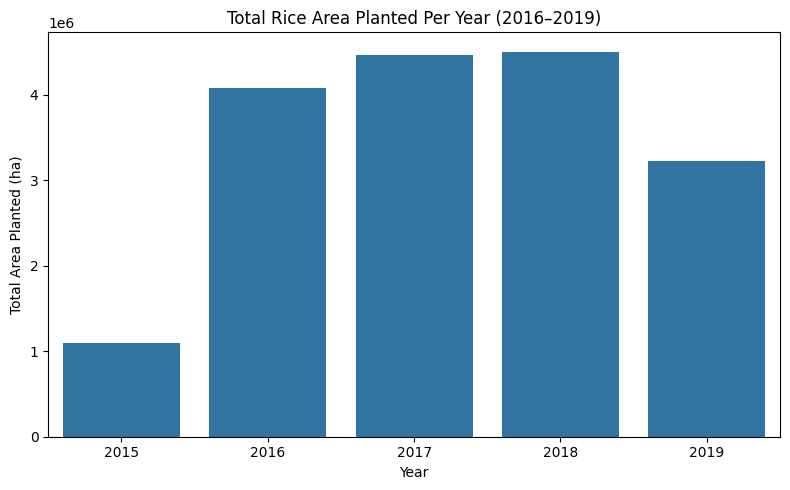

In [3]:
# Total per year
yearly_total = df_long.groupby("year")["area_ha"].sum()

plt.figure(figsize=(8, 5))
sns.barplot(x=yearly_total.index, y=yearly_total.values)
plt.title("Total Rice Area Planted Per Year (2016–2019)")
plt.xlabel("Year")
plt.ylabel("Total Area Planted (ha)")
plt.tight_layout()
plt.show()


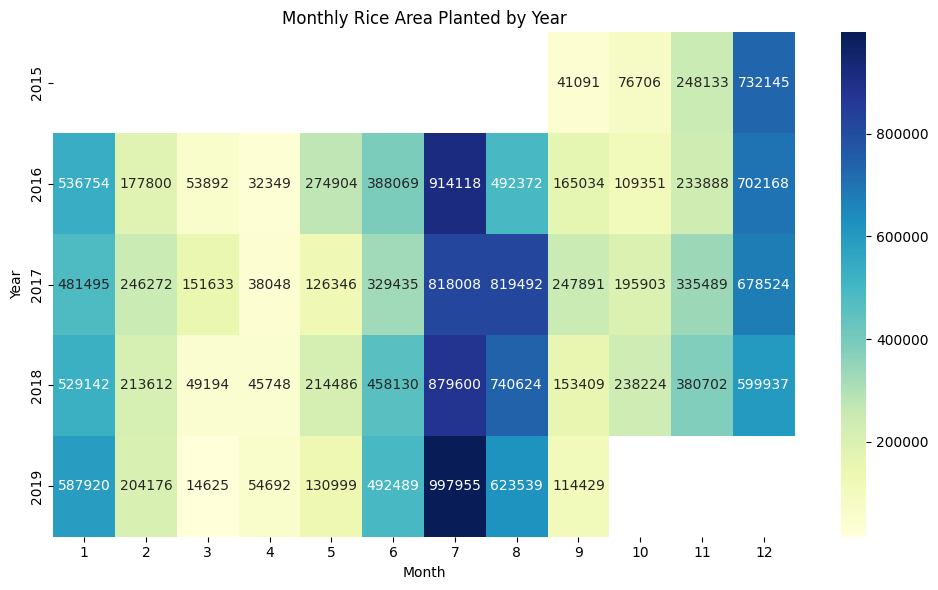

In [4]:
monthly_yearly = df_long.groupby(["year", "month"])["area_ha"].sum().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(monthly_yearly, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Monthly Rice Area Planted by Year")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()


C:\Users\ilyag\AppData\Local\Temp\ipykernel_51604\3634880371.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_months = df_long.groupby("ADM3_PCODE").apply(weighted_mean_month).reset_index(name="mean_month")


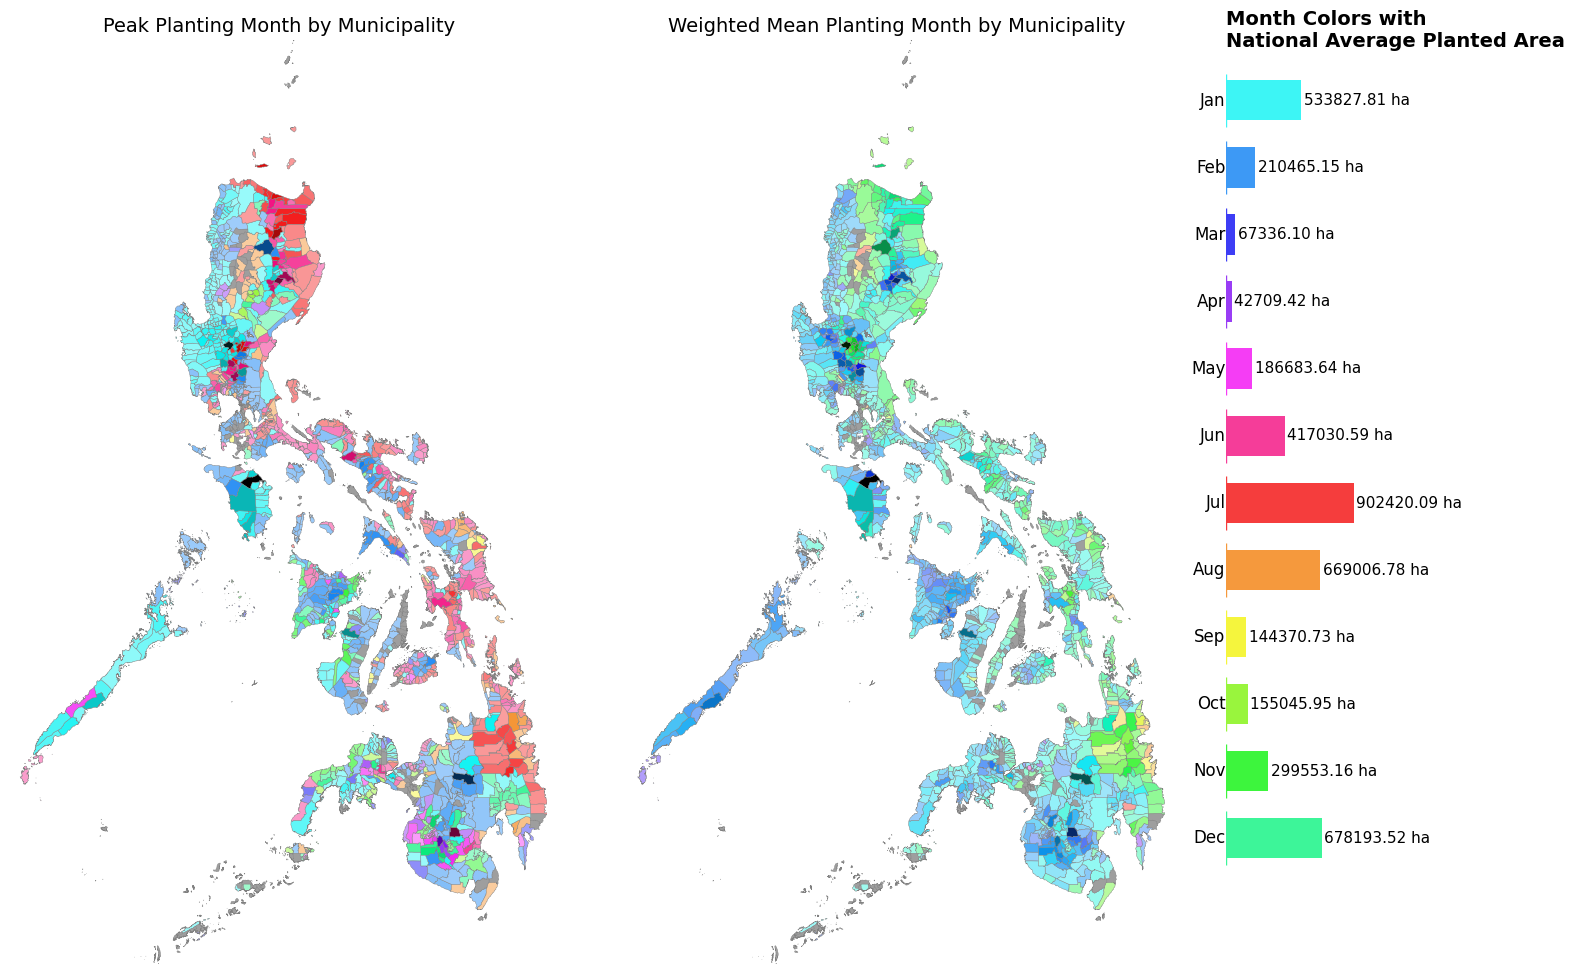

In [15]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 12))

# ======================================================================
# FIRST PLOT: PEAK MONTH
# ======================================================================

# Step 1: Compute peak planting month (month with max avg area) per municipality
monthly_avg = df_long.groupby(["ADM3_PCODE", "month"])["area_ha"].mean().reset_index()
peak_months_idx = monthly_avg.groupby("ADM3_PCODE")["area_ha"].idxmax()
peak_months = monthly_avg.loc[peak_months_idx, ["ADM3_PCODE", "month"]].rename(columns={"month": "peak_month"})

peak_months = peak_months.merge(
    monthly_avg.groupby("ADM3_PCODE")["area_ha"].max().rename("max_area"),
    on="ADM3_PCODE"
)
# Set peak_month to NA where max area is 0
peak_months.loc[peak_months["max_area"] == 0, "peak_month"] = pd.NA
# Drop the temporary column
peak_months = peak_months.drop(columns="max_area")

# Step 2: Compute average total planting area per municipality (magnitude)
avg_area = df_long.groupby("ADM3_PCODE")["area_ha"].mean().reset_index(name="avg_area")

# Step 3: Merge summary statistics
summary_peak = peak_months.merge(avg_area, on="ADM3_PCODE", how="left")

# Step 4: Load shapefile and merge
gdf = gpd.read_file("phl_administrative_boundaries/phl_admbnda_adm3.shp")
map_df_peak = gdf.merge(summary_peak, on="ADM3_PCODE", how="left")

# Get current bounds and adjust left (xmin) by 20% of total width
xmin, ymin, xmax, ymax = gdf.total_bounds
width = xmax - xmin
adjusted_xmin = xmin + width * 0.2  # Cut 20% from left
plot_bounds = [adjusted_xmin, ymin, xmax, ymax]

# Step 5: Normalize for HLS color mapping
map_df_peak["hue"] = ((map_df_peak["peak_month"] - 1) % 12) / 12.0
min_area = map_df_peak["avg_area"].min()
max_area = map_df_peak["avg_area"].max()
map_df_peak["lightness"] = 0.8 - 0.8 * (map_df_peak["avg_area"] - min_area) / (max_area - min_area)
map_df_peak["saturation"] = 0.9

# Step 6: Convert HLS to RGB
from colorsys import hls_to_rgb
map_df_peak["color"] = map_df_peak.apply(lambda row: hls_to_rgb(row["hue"], row["lightness"], row["saturation"]), axis=1)

# Plot peak month map
map_df_peak.plot(color=map_df_peak["color"].tolist(), edgecolor="grey", linewidth=0.3, ax=ax1)
ax1.set_title("Peak Planting Month by Municipality", fontsize=14)
ax1.set_xlim(plot_bounds[0], plot_bounds[2])  # xmin, xmax
ax1.set_ylim(plot_bounds[1], plot_bounds[3])  # ymin, ymax
ax1.axis("off")

# ======================================================================
# SECOND PLOT: WEIGHTED MEAN MONTH
# ======================================================================

# Step 1: Compute weighted mean planting month per municipality
def weighted_mean_month(group):
    if group["area_ha"].sum() > 0:
        return np.average(group["month"], weights=group["area_ha"])
    else:
        return np.nan

weighted_months = df_long.groupby("ADM3_PCODE").apply(weighted_mean_month).reset_index(name="mean_month")

# Step 3: Merge summary statistics
summary_weighted = weighted_months.merge(avg_area, on="ADM3_PCODE", how="left")

# Step 4: Merge with shapefile
map_df_weighted = gdf.merge(summary_weighted, on="ADM3_PCODE", how="left")

# Step 5: Normalize for HLS color mapping
map_df_weighted["hue"] = ((map_df_weighted["mean_month"] - 1) % 12) / 12.0
map_df_weighted["lightness"] = 0.8 - 0.8 * (map_df_weighted["avg_area"] - min_area) / (max_area - min_area)
map_df_weighted["saturation"] = 0.9

# Step 6: Convert HLS to RGB
map_df_weighted["color"] = map_df_weighted.apply(lambda row: hls_to_rgb(row["hue"], row["lightness"], row["saturation"]), axis=1)

# Plot weighted mean month map
map_df_weighted.plot(color=map_df_weighted["color"].tolist(), edgecolor="grey", linewidth=0.3, ax=ax2)
ax2.set_title("Weighted Mean Planting Month by Municipality", fontsize=14)
ax2.set_xlim(plot_bounds[0], plot_bounds[2])  # xmin, xmax
ax2.set_ylim(plot_bounds[1], plot_bounds[3])  # ymin, ymax
ax2.axis("off")

# ======================================================================
# SHARED LEGEND
# ======================================================================

# Calculate national avg area per month (shared between both plots)
monthly_sum = df_long.groupby(["year", "month", "ADM3_PCODE"])["area_ha"].sum().reset_index()
total_per_month_year = monthly_sum.groupby(["year", "month"])["area_ha"].sum().reset_index()
month_avg_area = total_per_month_year.groupby("month")["area_ha"].mean().reindex(range(1, 13)).fillna(0)
month_avg_area_rounded = month_avg_area.round(2)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_colors = [hls_to_rgb(((m + 6) % 12) / 12, 0.6, 0.9) for m in range(12)]

# Create shared legend on the right side
legend_ax = inset_axes(
    ax2,
    width="25%", height="90%",
    loc="center left",
    bbox_to_anchor=(1.1, 0.05, 1, 1),
    bbox_transform=ax2.transAxes
)
legend_ax.axis("off")
legend_ax.set_ylim(-0.9, 11.5)
legend_ax.invert_yaxis()

# Draw labels, patches, and bars
for i, (label, color, area_val) in enumerate(zip(month_labels, month_colors, month_avg_area_rounded)):
    y = i
    # Month label
    legend_ax.text(-0.5, y, label, va='center', ha='right', fontsize=12)
    # Color patch
    legend_ax.add_patch(plt.Rectangle((0.6, y - 0.4), 0.4, 0.8, color=color, transform=legend_ax.transData))
    # Bar (no extra line)
    legend_ax.barh(y, area_val, height=0.6, left=1.2, color=color)
    # Numeric label
    legend_ax.text(1.2 + area_val + (month_avg_area.max() * 0.02), y,
                   f"{area_val:.2f} ha", va='center', ha='left', fontsize=11)

# Legend title
legend_ax.text(-0.8, -0.8,
               "Month Colors with \nNational Average Planted Area",
               fontsize=14, fontweight='bold', ha='left')

# Adjust layout to make room for the legend
plt.subplots_adjust(left=0.05, right=0.8, wspace=-0.3)

plt.savefig("figures/philippines_rice_patterns.svg", bbox_inches='tight')
plt.savefig("figures/philippines_rice_patterns.pdf", bbox_inches='tight')
plt.savefig("figures/philippines_rice_patterns.png", dpi='figure', bbox_inches='tight')

plt.show()

Observations

C:\Users\ilyag\AppData\Local\Temp\ipykernel_57184\3931163048.py:175: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(fontsize=ANNOTATION_FONT_SIZE, loc="lower left", title="Typhoon Category", title_fontsize=ANNOTATION_FONT_SIZE)


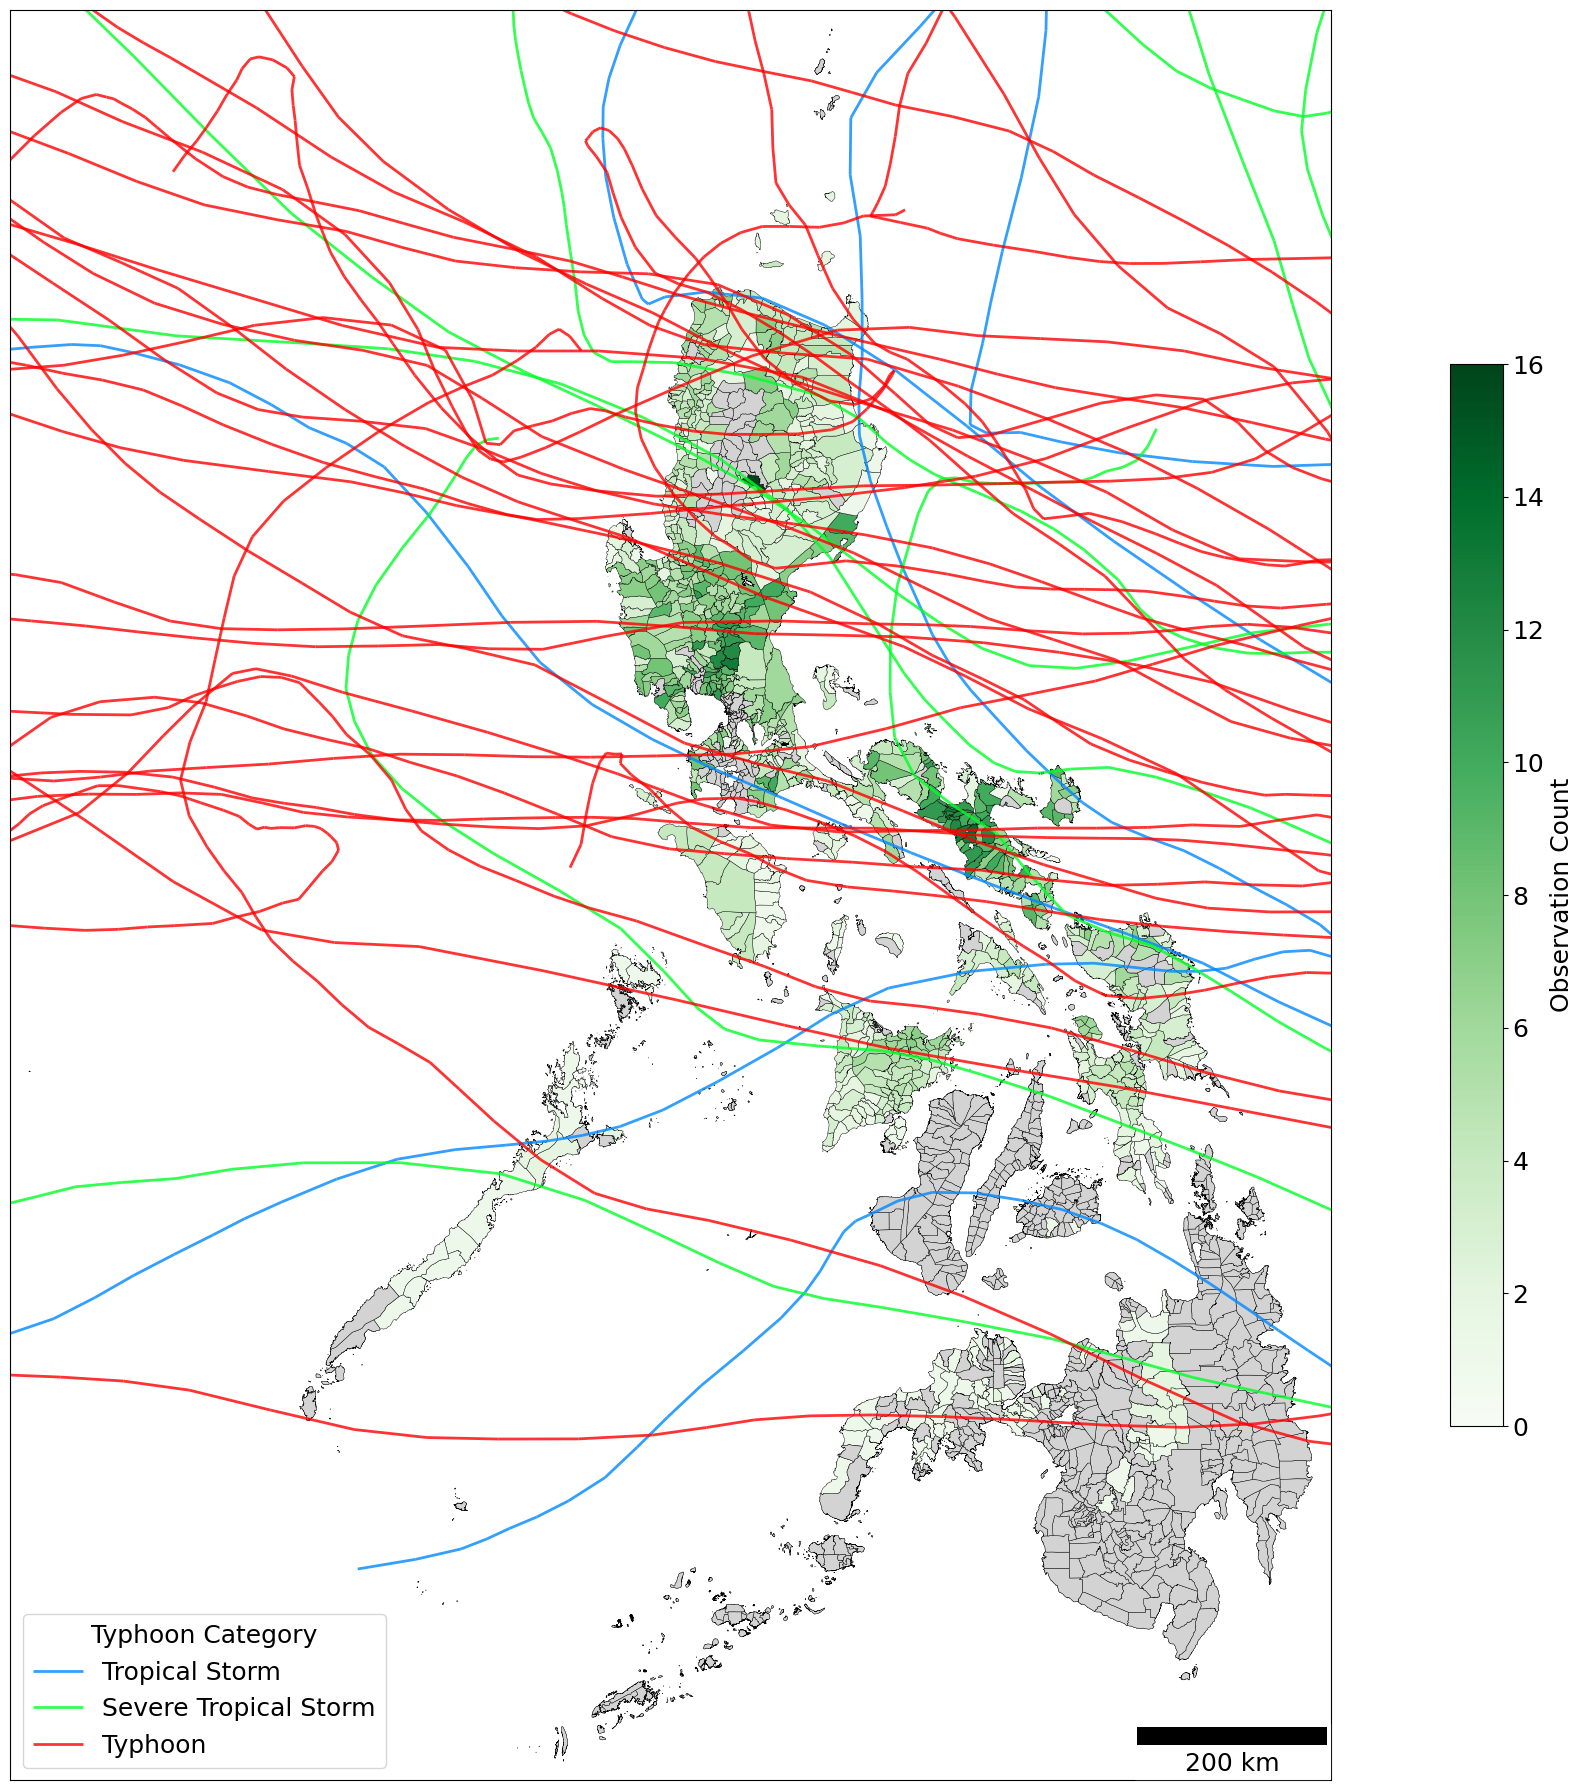

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
import os
from matplotlib_scalebar.scalebar import ScaleBar
import numpy as np

# Font sizes
LABEL_FONT_SIZE = 20
TITLE_FONT_SIZE = 22
ANNOTATION_FONT_SIZE = 18


# Load municipality shapefile
municipalities_path = 'phl_administrative_boundaries/phl_admbnda_adm3.shx'
municipalities = gpd.read_file(municipalities_path)

# Load loss data
loss_data_path = 'restricted_data/combined_input_data/input_data_05_lf.xlsx'
loss_data = pd.read_excel(loss_data_path)
loss_data = loss_data[~loss_data['area_affected'].isna()]

# Count observations per municipality
municipality_observation_counts = (
    loss_data.groupby('mun_code').size().reset_index(name='observation_count')
)

# Merge with municipality shapefile
municipalities_with_counts = municipalities.merge(
    municipality_observation_counts, left_on='ADM3_PCODE', right_on='mun_code', how='left'
)
municipalities_with_counts['observation_count'] = municipalities_with_counts['observation_count'].fillna(0)

# Load typhoon tracks shapefile
typhoon_tracks_path = 'gis_data/typhoon_tracks'
typhoon_tracks = gpd.read_file(typhoon_tracks_path)

# Ensure 'WMO_WIND' is numeric and handle potential missing/non-numeric values
typhoon_tracks['WMO_WIND'] = pd.to_numeric(typhoon_tracks['WMO_WIND'], errors='coerce')

# Define the classification function based on JMA/WMO thresholds
def classify_typhoon_scale(wind_speed_knots):
    """
    Classifies a typhoon point based on its 10-minute sustained wind speed (in knots)
    according to JMA/WMO Western North Pacific categories.
    """
    if pd.isna(wind_speed_knots):
        return pd.NA
    elif wind_speed_knots >= 130:
        return "Super Typhoon"
    elif wind_speed_knots >= 64:
        return "Typhoon"
    elif wind_speed_knots >= 48:
        return "Severe Tropical Storm"
    elif wind_speed_knots >= 34:
        return "Tropical Storm"
    else: # Less than 34 knots
        return "Tropical Depression"

# Apply the classification function to create a new 'point_category' column for each point
typhoon_tracks['point_category'] = typhoon_tracks['WMO_WIND'].apply(classify_typhoon_scale)

# Define an ordered list of categories from weakest to strongest
category_order = {
    "Tropical Depression": 1,
    "Tropical Storm": 2,
    "Severe Tropical Storm": 3,
    "Typhoon": 4,
    "Super Typhoon": 5,
}

# Create a numerical representation of the category for comparison
typhoon_tracks['category_rank'] = typhoon_tracks['point_category'].map(category_order)

# Group by Storm ID (SID) and find the maximum category rank for each storm
max_category_per_storm = typhoon_tracks.groupby('SID')['category_rank'].max().reset_index()

# Map the numerical rank back to the category name
reverse_category_order = {v: k for k, v in category_order.items()}
max_category_per_storm['peak_category'] = max_category_per_storm['category_rank'].map(reverse_category_order)

# Merge the overall peak category back to the original typhoon_tracks GeoDataFrame
typhoon_tracks = typhoon_tracks.merge(
    max_category_per_storm[['SID', 'peak_category']],
    on='SID',
    how='left'
)

# Reproject to UTM Zone 51N (adjust if needed for your area)
target_crs = "EPSG:32651"
municipalities_with_counts = municipalities_with_counts.to_crs(target_crs)
typhoon_tracks = typhoon_tracks.to_crs(target_crs)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(24, 18))


### Observation Count Colormap Update

# Define NEW colormap for Observation Count
cmap_obs_count = 'Greens'

# Plot municipalities with new colormap
municipalities_with_counts.plot(
    column='observation_count',
    cmap=cmap_obs_count,
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    legend_kwds={
        'label': "Observation Count",
        'orientation': "vertical",
        'shrink': 0.6,
    },
    ax=ax
)

# Fix colorbar font size
cbar = ax.get_figure().get_axes()[-1]
cbar.tick_params(labelsize=ANNOTATION_FONT_SIZE)
cbar.set_ylabel("Observation Count", fontsize=ANNOTATION_FONT_SIZE)

# Highlight municipalities with no data
municipalities_with_counts[municipalities_with_counts['observation_count'] == 0].plot(
    ax=ax, color="lightgrey", edgecolor="black", linewidth=0.3, label="No Data"
)


# Define plotting parameters for each category
track_styles = {
    "Tropical Depression": {'color': '#ADD8E6', 'linewidth': 1.4, 'alpha': 0.8}, # Light Blue
    "Tropical Storm": {'color': "#0088FF", 'linewidth': 2, 'alpha': 0.8},    # Thicker Blue
    "Severe Tropical Storm": {'color': "#00FF26", 'linewidth': 2, 'alpha': 0.8}, # Red
    "Typhoon": {'color': '#FF0000', 'linewidth': 2, 'alpha': 0.8},          # Thicker Red
    "Super Typhoon": {'color': '#8B0000', 'linewidth': 3.3, 'alpha': 0.9}, # Dark Red, even thicker
}

# Plot each category of typhoon track in order of increasing intensity
# This ensures thicker lines for stronger categories are drawn on top if they overlap.
for category_name in category_order.keys(): # Iterate using the defined order
    style = track_styles.get(category_name)
    if style: # Check if style exists for category
        # Filter tracks where the *peak category* of the storm matches the current category
        category_tracks = typhoon_tracks[typhoon_tracks['peak_category'] == category_name]
        if not category_tracks.empty:
            category_tracks.plot(
                ax=ax,
                color=style['color'],
                linewidth=style['linewidth'],
                alpha=style['alpha'],
                label=category_name, # Label for the legend
                rasterized=True
            )

# Remove axis labels and ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# Set plot bounds with buffer
bounds = municipalities_with_counts.total_bounds
buffer = 20000  # in meters (20 km buffer)
ax.set_xlim(bounds[0] - buffer, bounds[2] + buffer)
ax.set_ylim(bounds[1] - buffer, bounds[3] + buffer)

# Add scale bar
scalebar = ScaleBar(1, units='m', location='lower right', box_alpha=0.5,
                     font_properties={'size': ANNOTATION_FONT_SIZE})
ax.add_artist(scalebar)

# Adjust legend and layout
# Matplotlib will now automatically collect labels from the individual plot calls
plt.legend(fontsize=ANNOTATION_FONT_SIZE, loc="lower left", title="Typhoon Category", title_fontsize=ANNOTATION_FONT_SIZE)
plt.tight_layout()

# Save the figure in both PDF and SVG formats for high quality
plt.savefig("figures/municipality_typhoon_map.pdf", format="pdf", bbox_inches="tight", dpi='figure')
plt.savefig("figures/municipality_typhoon_map.svg", format="svg", bbox_inches="tight", dpi='figure')
plt.savefig("figures/municipality_typhoon_map.png", format="png", bbox_inches="tight", dpi='figure')

# Show the plot
plt.show()

C:\Users\ilyag\AppData\Local\Temp\ipykernel_81236\3009720163.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the main colorbar and minimize margins


Plot saved to 'figures' as PNG, PDF, and SVG.


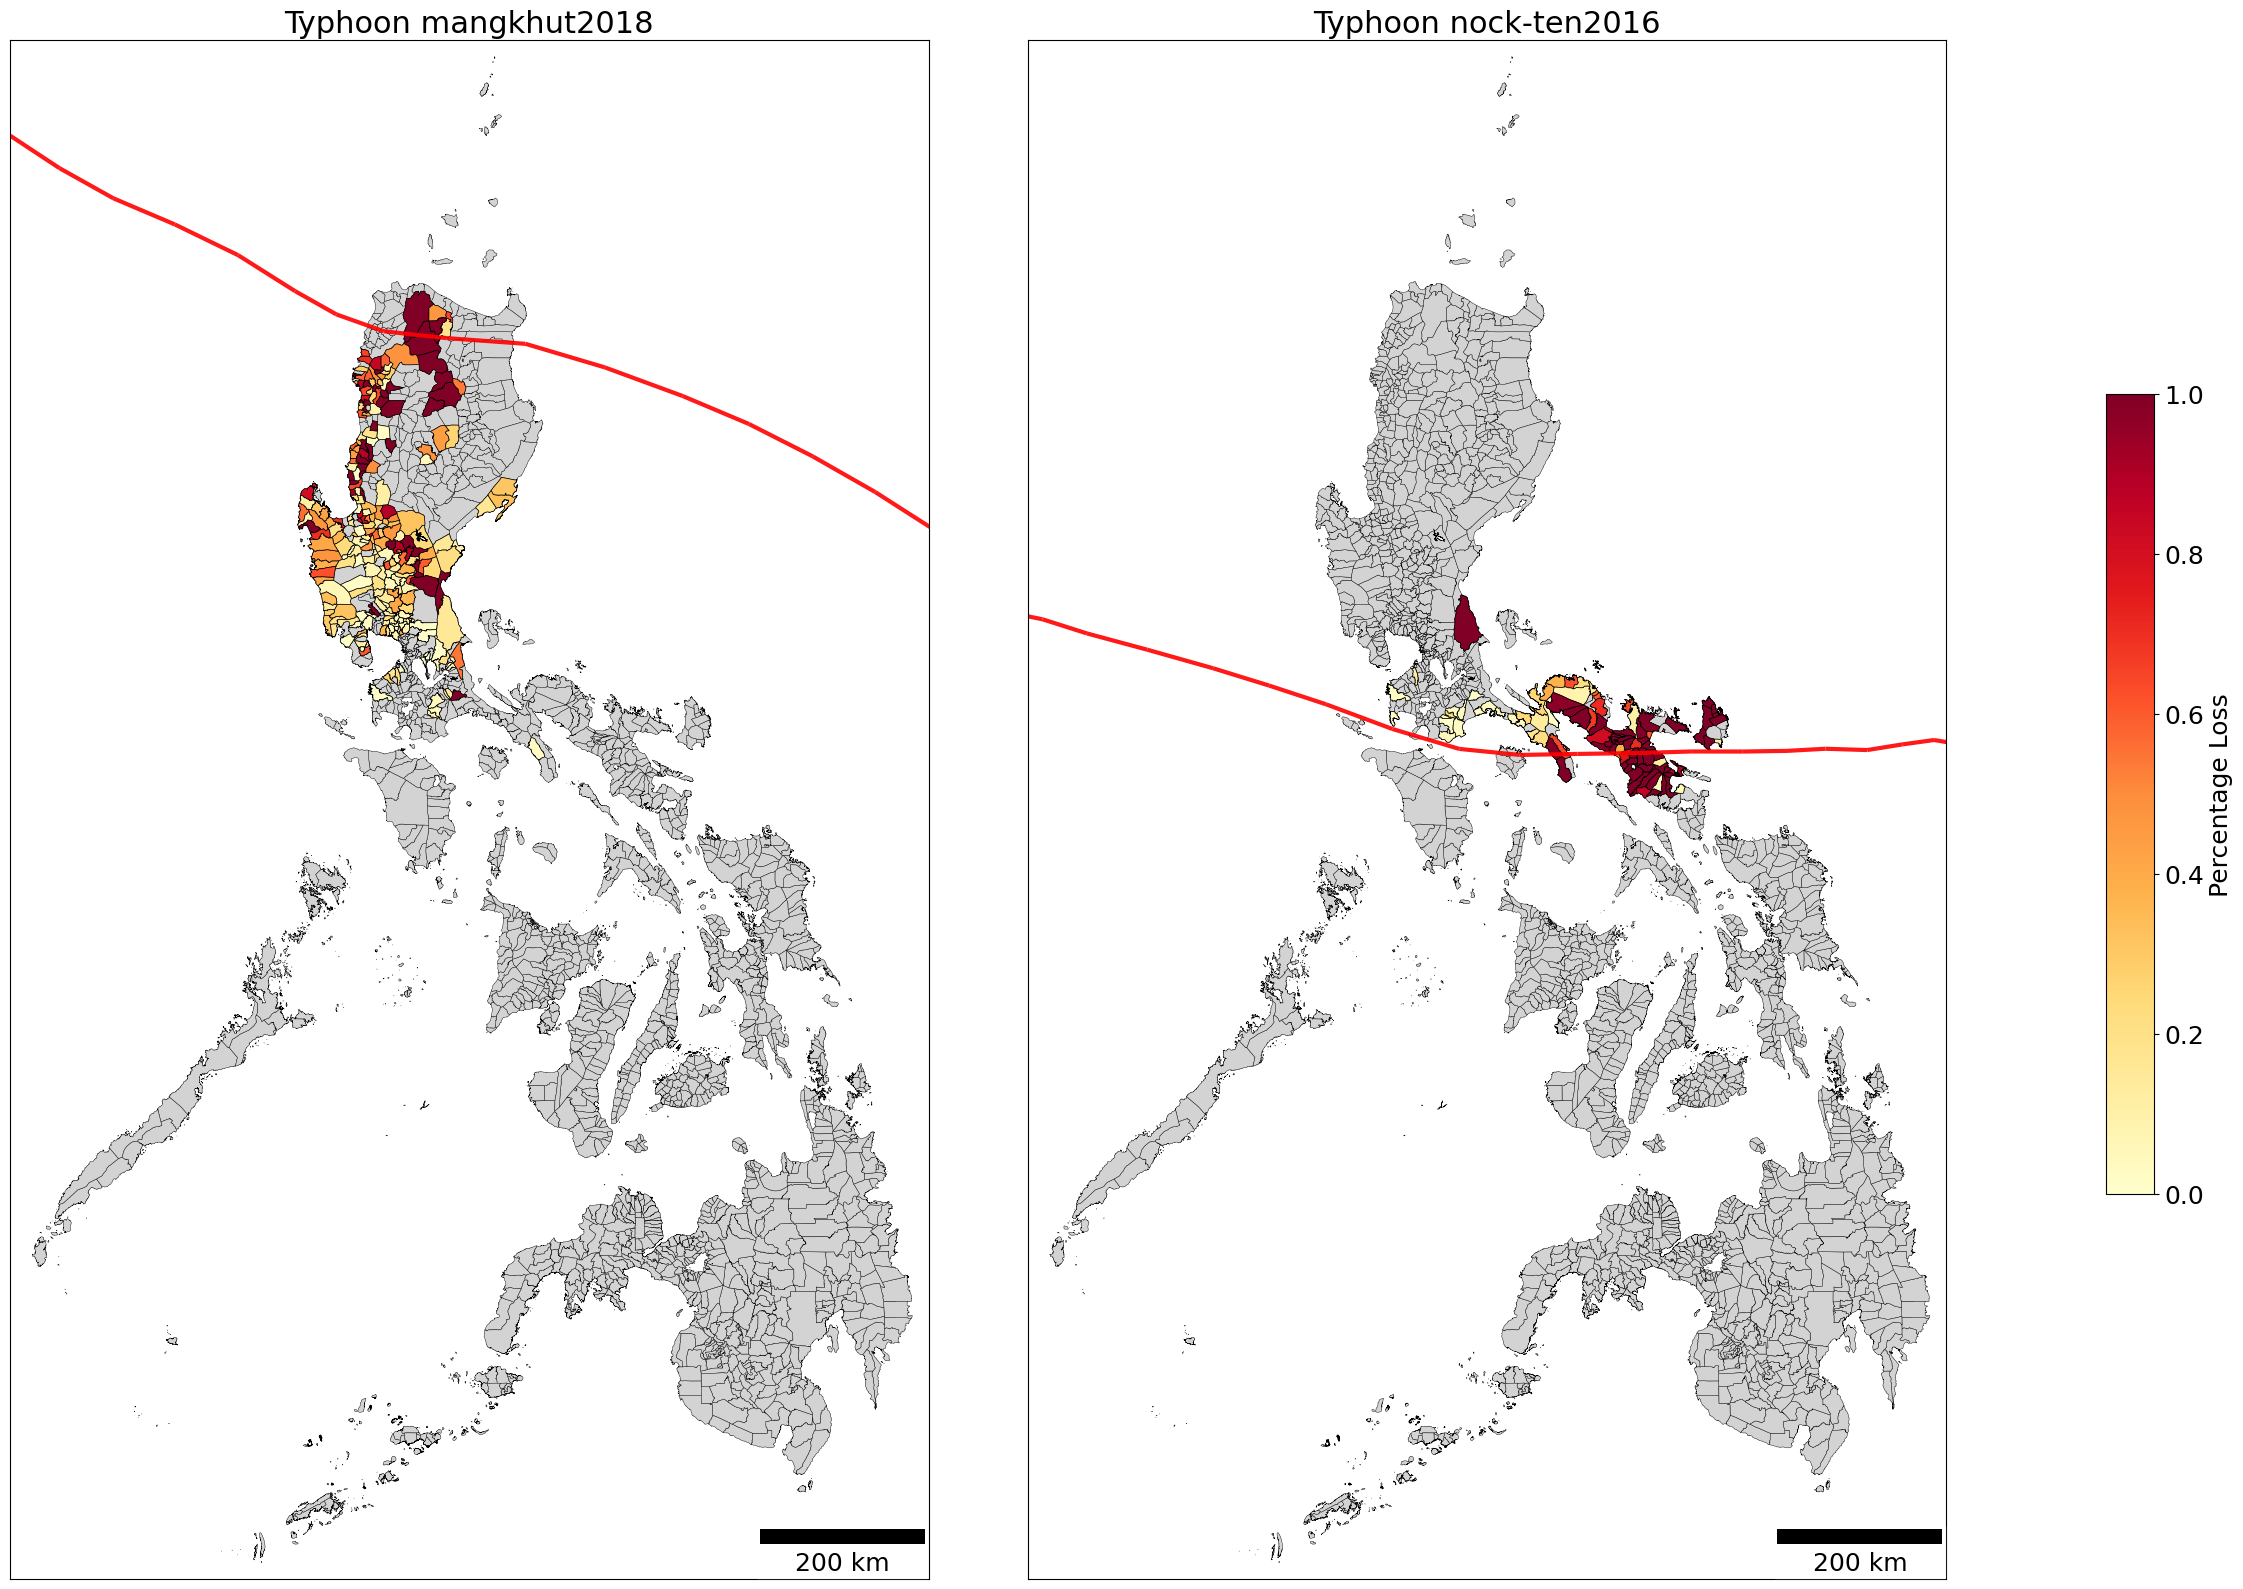

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
import os
from matplotlib_scalebar.scalebar import ScaleBar
import numpy as np

# Font sizes
LABEL_FONT_SIZE = 20
TITLE_FONT_SIZE = 22
ANNOTATION_FONT_SIZE = 18

# Load municipality shapefile
municipalities_path = 'phl_administrative_boundaries/phl_admbnda_adm3.shx'
municipalities = gpd.read_file(municipalities_path)

# Load loss data
loss_data_path = 'restricted_data/combined_input_data/input_data_05_lf.xlsx'
loss_data = pd.read_excel(loss_data_path)
loss_data = loss_data[~loss_data['area_affected'].isna()] # Filter out NA area_affected

# Load typhoon tracks shapefile
typhoon_tracks_path = 'gis_data/typhoon_tracks'
typhoon_tracks = gpd.read_file(typhoon_tracks_path)

# Ensure 'WMO_WIND' is numeric and handle potential missing/non-numeric values
typhoon_tracks['WMO_WIND'] = pd.to_numeric(typhoon_tracks['WMO_WIND'], errors='coerce')

# Define the classification function based on JMA/WMO thresholds
def classify_typhoon_scale(wind_speed_knots):
    """
    Classifies a typhoon point based on its 10-minute sustained wind speed (in knots)
    according to JMA/WMO Western North Pacific categories.
    """
    if pd.isna(wind_speed_knots):
        return pd.NA
    elif wind_speed_knots >= 130:
        return "Super Typhoon"
    elif wind_speed_knots >= 64:
        return "Typhoon"
    elif wind_speed_knots >= 48:
        return "Severe Tropical Storm"
    elif wind_speed_knots >= 34:
        return "Tropical Storm"
    else: # Less than 34 knots
        return "Tropical Depression"

# Apply the classification function to create a new 'point_category' column for each point
typhoon_tracks['point_category'] = typhoon_tracks['WMO_WIND'].apply(classify_typhoon_scale)

# Define an ordered list of categories from weakest to strongest (not strictly needed for this plot's track style)
category_order = {
    "Tropical Depression": 1,
    "Tropical Storm": 2,
    "Severe Tropical Storm": 3,
    "Typhoon": 4,
    "Super Typhoon": 5,
}

# Create a numerical representation of the category for comparison
typhoon_tracks['category_rank'] = typhoon_tracks['point_category'].map(category_order)

# Group by Storm ID (SID) and find the maximum category rank for each storm
max_category_per_storm = typhoon_tracks.groupby('SID')['category_rank'].max().reset_index()

# Map the numerical rank back to the category name
reverse_category_order = {v: k for k, v in category_order.items()}
max_category_per_storm['peak_category'] = max_category_per_storm['category_rank'].map(reverse_category_order)

# Merge the overall peak category back to the original typhoon_tracks GeoDataFrame
typhoon_tracks = typhoon_tracks.merge(
    max_category_per_storm[['SID', 'peak_category']],
    on='SID',
    how='left'
)

# Reproject to UTM Zone 51N (adjust if needed for your area) - Do this once
target_crs = "EPSG:32651"
municipalities = municipalities.to_crs(target_crs)
typhoon_tracks = typhoon_tracks.to_crs(target_crs)

# Define the two specific typhoons to plot
target_sids = ['2018250N12170', '2016355N07146']

# Create a directory for figures if it doesn't exist
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# Create a figure with 1 row and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(24, 16)) # Adjusted figsize to accommodate cropping

# Determine the global min/max for perc_loss for consistent colorbar
# Filter loss_data for only the target SIDs to get relevant perc_loss range
relevant_loss_data = loss_data[loss_data['storm_id'].isin(target_sids)]
vmin_loss = relevant_loss_data['perc_loss'].min()
vmax_loss = relevant_loss_data['perc_loss'].max()

# Define colormap for perc_loss
cmap_perc_loss = 'YlOrRd' # Yellow-Orange-Red, good for percentages/intensity

for i, sid in enumerate(target_sids):
    ax = axs[i] # Get the current subplot axis

    # Filter typhoon tracks for the current storm
    current_typhoon_track = typhoon_tracks[typhoon_tracks['SID'] == sid]

    # Filter loss data for the current storm
    current_storm_loss_data = loss_data[loss_data['storm_id'] == sid]

    # Get the typhoon name
    typhoon_name = current_storm_loss_data['typhoon'].iloc[0] if not current_storm_loss_data.empty else sid

    # Merge current_storm_loss_data with municipality geometries
    # Ensure 'mun_code' in loss_data matches 'ADM3_PCODE' in municipalities
    affected_municipalities_data = municipalities.merge(
        current_storm_loss_data, left_on='ADM3_PCODE', right_on='mun_code', how='inner'
    )

    # Plot all municipalities as a base layer (light grey)
    municipalities.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.3)

    # Plot affected municipalities by perc_loss
    if not affected_municipalities_data.empty:
        plot_mappable = affected_municipalities_data.plot(
            column='perc_loss',
            cmap=cmap_perc_loss,
            linewidth=0.5,
            edgecolor='black',
            ax=ax,
            vmin=vmin_loss, # Use global min/max for consistent coloring
            vmax=vmax_loss,
        )
    else:
        print(f"No loss data found for SID: {sid} within municipalities.")


    # Plot the typhoon track as a thick red line (no legend for the track)
    if not current_typhoon_track.empty:
        current_typhoon_track.plot(
            ax=ax,
            color='red',
            linewidth=3.0, # Thick red line
            alpha=0.9,
            rasterized=True # Speeds up rendering
        )

    # Remove axis labels and ticks
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Set plot bounds with buffer and apply left crop
    bounds = municipalities.total_bounds
    buffer = 20000  # in meters (20 km buffer)
    original_xlim_min = bounds[0] - buffer
    original_xlim_max = bounds[2] + buffer
    original_width = original_xlim_max - original_xlim_min

    # Calculate new left boundary to cut 20% from the left
    new_xlim_min = original_xlim_min + (0.20 * original_width) # Remove 20% from the left
    ax.set_xlim(new_xlim_min, original_xlim_max)
    ax.set_ylim(bounds[1] - buffer, bounds[3] + buffer)

    # Add scale bar
    scalebar = ScaleBar(1, units='m', location='lower right', box_alpha=0.5,
                        font_properties={'size': ANNOTATION_FONT_SIZE})
    ax.add_artist(scalebar)

    # Set subplot title to typhoon name
    ax.set_title(f"Typhoon {typhoon_name}", fontsize=TITLE_FONT_SIZE)

# Add a single colorbar for perc_loss for the entire figure
sm = plt.cm.ScalarMappable(cmap=cmap_perc_loss, norm=plt.Normalize(vmin=vmin_loss, vmax=vmax_loss))
sm._A = []

# Create the colorbar in the figure
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5]) # [left, bottom, width, height] in figure coordinates
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Percentage Loss', fontsize=ANNOTATION_FONT_SIZE)
cbar.ax.tick_params(labelsize=ANNOTATION_FONT_SIZE)

# Minimize whitespace globally
plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the main colorbar and minimize margins

# Save the figure
filename_prefix = os.path.join(output_dir, "selected_typhoons_perc_loss_with_tracks")
plt.savefig(f"{filename_prefix}.pdf", format="pdf", bbox_inches="tight", dpi='figure')
plt.savefig(f"{filename_prefix}.svg", format="svg", bbox_inches="tight", dpi='figure')
plt.savefig(f"{filename_prefix}.png", format="png", bbox_inches="tight", dpi='figure')

print(f"Plot saved to '{output_dir}' as PNG, PDF, and SVG.")

# Display the plot
plt.show()